Chr1 length: 30,427,671 bp
Building genome-wide k-mer repeat set … (may take ~30 s)
Done — 587,396 k-mers are multi-copy in Chr1.

Centromere region  (smoothed global repeat score > 0.05):
  Start  :   12,380,000 bp   (12.38 Mb)
  End    :   16,840,000 bp   (16.84 Mb)
  Length :    4,460,000 bp   (4.46 Mb)


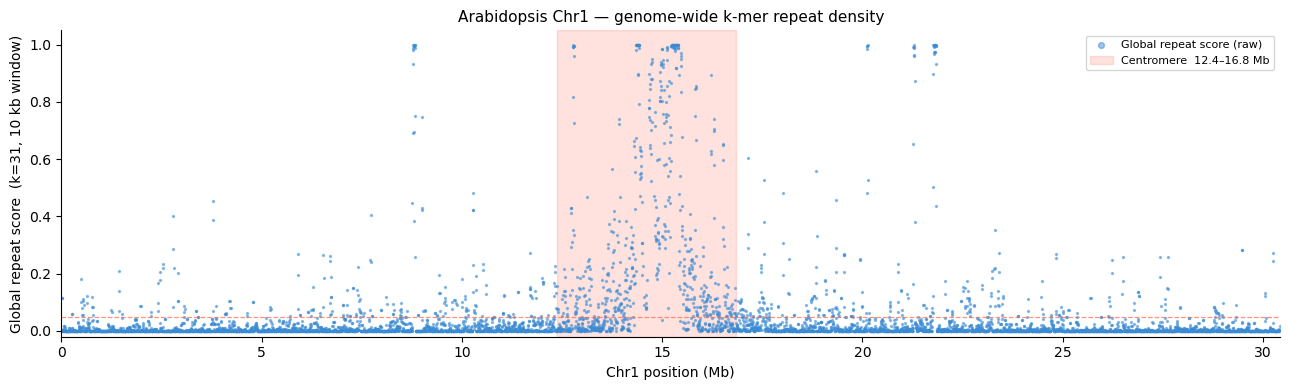

In [1]:
from Bio import SeqIO
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ── parameters ───────────────────────────────────────────────────────────────
FASTA          = "/Users/tatiana/Documents_new/visor_freqk/data/reference/Chr1.fa"
WINDOW         = 10_000   # bp per window
STEP           =  5_000   # step between windows
K              =     31   # k-mer size (matches short-read seed)
CENTRO_THRESH  =   0.05   # repeat-score threshold for calling a window centromeric
SMOOTH_BP      = 200_000  # Gaussian smoothing width (bp) before centromere detection

# ── positions already simulated ───────────────────────────────────────────────
SIMULATED = {
    "pos10mb":  10_000_000,
    "pos20mb":  20_000_000,
    "pos15mb":  15_000_000,
    "pos152mb": 15_200_000,
}

# ── genome-wide repeat set ────────────────────────────────────────────────────
# A k-mer is "repeated" if it appears ≥2× anywhere in Chr1.
# This matches what freqk actually does: k-mers with genome-wide count > 1
# are treated as non-unique and filtered out.
#
# Uses two-pass set approach to avoid storing full counts:
#   pass 1: collect k-mers into seen_once / repeated sets
#   pass 2: free seen_once — only repeated (smaller) set is kept
#
def build_repeat_set(ref_seq: str, k: int = K) -> frozenset:
    """Return frozenset of all k-mers that appear ≥2× in ref_seq."""
    seen_once = set()
    repeated  = set()
    seq_clean = ref_seq.replace("N", "")
    for i in range(len(seq_clean) - k + 1):
        km = seq_clean[i : i + k]
        if km in seen_once:
            repeated.add(km)
        else:
            seen_once.add(km)
    del seen_once   # free ~2 GB; only repeated set (~10–20% of k-mers) is kept
    return frozenset(repeated)

def global_repeat_score(seq: str, repeat_set: frozenset, k: int = K) -> float:
    """
    Fraction of k-mers in seq that appear ≥2× anywhere in the reference genome.
    0 = all k-mers in this window are globally unique (freqk can use them all).
    1 = all k-mers are multi-copy genome-wide (freqk would filter all of them).
    """
    seq = seq.replace("N", "")
    total = len(seq) - k + 1
    if total <= 0:
        return np.nan
    n_rep = sum(1 for i in range(total) if seq[i : i + k] in repeat_set)
    return n_rep / total

# ── load reference ────────────────────────────────────────────────────────────
record    = next(SeqIO.parse(FASTA, "fasta"))
seq       = str(record.seq).upper()
chrom_len = len(seq)
print(f"Chr1 length: {chrom_len:,} bp")

print("Building genome-wide k-mer repeat set … (may take ~30 s)", flush=True)
genome_repeat_set = build_repeat_set(seq)
print(f"Done — {len(genome_repeat_set):,} k-mers are multi-copy in Chr1.\n")

# ── chromosome-wide scan (global repeat score per window) ─────────────────────
mids, scores = [], []
for i in range(0, chrom_len - WINDOW, STEP):
    w = seq[i : i + WINDOW]
    if w.count("N") / WINDOW > 0.5:
        continue
    mids.append(i + WINDOW // 2)
    scores.append(global_repeat_score(w, genome_repeat_set))

mids   = np.array(mids)
scores = np.array(scores)

# ── smooth scores before centromere detection ─────────────────────────────────
from scipy.ndimage import gaussian_filter1d
sigma_windows = max(1, round(SMOOTH_BP / STEP))
scores_smooth = gaussian_filter1d(scores, sigma=sigma_windows)

# ── detect centromere: largest contiguous run of high-repeat windows ──────────
above = scores_smooth > CENTRO_THRESH
runs, in_run = [], False
for j, v in enumerate(above):
    if v and not in_run:
        run_start = j;  in_run = True
    elif not v and in_run:
        runs.append((run_start, j - 1)); in_run = False
if in_run:
    runs.append((run_start, len(above) - 1))

longest      = max(runs, key=lambda r: r[1] - r[0])
centro_start = mids[longest[0]] - WINDOW // 2
centro_end   = mids[longest[1]] + WINDOW // 2

print(f"Centromere region  (smoothed global repeat score > {CENTRO_THRESH}):")
print(f"  Start  : {centro_start:>12,} bp   ({centro_start / 1e6:.2f} Mb)")
print(f"  End    : {centro_end:>12,} bp   ({centro_end   / 1e6:.2f} Mb)")
print(f"  Length : {centro_end - centro_start:>12,} bp   ({(centro_end - centro_start) / 1e6:.2f} Mb)")

# ── single plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))

ax.scatter(mids / 1e6, scores, s=2, c="#3B8BD4", alpha=0.5, rasterized=True, zorder=2,
           label="Global repeat score (raw)")

ax.axvspan(centro_start / 1e6, centro_end / 1e6, alpha=0.18, color="tomato", zorder=1,
           label=f"Centromere  {centro_start/1e6:.1f}–{centro_end/1e6:.1f} Mb")
ax.axhline(CENTRO_THRESH, color="tomato", lw=0.9, ls="--", alpha=0.7)

ax.set_xlim(0, chrom_len / 1e6)
ax.set_ylim(-0.02, 1.05)
ax.set_xlabel("Chr1 position (Mb)", fontsize=10)
ax.set_ylabel(f"Global repeat score  (k={K}, {WINDOW//1000} kb window)", fontsize=10)
ax.set_title("Arabidopsis Chr1 — genome-wide k-mer repeat density", fontsize=11)
ax.legend(fontsize=8, loc="upper right", markerscale=3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


In [2]:

# ── Find 5 positions where deletion (all sizes) + flanks are all highly repetitive ──
#
# For each candidate position we compute:
#   - del_score_<size> : global repeat score of the deletion window for each size
#   - left_score       : mean global repeat score of 1 kb left flank
#   - right_score      : mean global repeat score of 1 kb right flank
#
# "Global repeat score" = fraction of k-mers in the window that appear ≥2×
# anywhere in Chr1 — this is what freqk actually uses to decide whether a
# k-mer is usable.  The old local metric (collisions within the window only)
# under-estimated repetitiveness for sequences like transposons or segmental
# duplications that are non-tandem but still shared across the genome.
#
# neighbourhood score = min(5kb_del, 10kb_del, left_flank, right_flank)

DEL_SIZES  = {"100bp": 100, "500bp": 500, "1kb": 1_000, "5kb": 5_000, "10kb": 10_000}
FLANK_BP   = 1_000
MIN_SEP    = 20_000   # minimum bp between selected candidates
MIN_SCORE  = 0.50     # applied to 5kb, 10kb del and both flanks

# pos_to_score uses the global scores computed in the previous cell
pos_to_score = dict(zip(mids - WINDOW // 2, scores))

def mean_score_region(start, end):
    vals = []
    s = (start // STEP) * STEP
    while s < end:
        v = pos_to_score.get(s)
        if v is not None and not np.isnan(v):
            vals.append(v)
        s += STEP
    return float(np.mean(vals)) if vals else np.nan

# ── scan ──────────────────────────────────────────────────────────────────────
candidates = []
max_del = max(DEL_SIZES.values())

for start in sorted(pos_to_score):
    if start + max_del + FLANK_BP >= chrom_len or start < FLANK_BP:
        continue
    # per-deletion global score (exact window, not interpolated)
    del_scores = {
        lbl: global_repeat_score(seq[start : start + sz], genome_repeat_set)
        for lbl, sz in DEL_SIZES.items()
    }
    left_s  = mean_score_region(start - FLANK_BP, start)
    right_s = mean_score_region(start + max_del, start + max_del + FLANK_BP)
    if any(np.isnan(v) for v in list(del_scores.values()) + [left_s, right_s]):
        continue
    nbhd = min(del_scores["5kb"], del_scores["10kb"], left_s, right_s)
    if nbhd >= MIN_SCORE:
        candidates.append((nbhd, del_scores, left_s, right_s, start))

candidates.sort(reverse=True)
print(f"Total candidates with global min_score ≥ {MIN_SCORE}: {len(candidates)}")

# ── greedy dedup (≥ MIN_SEP apart) ────────────────────────────────────────────
selected = []
for item in candidates:
    start = item[-1]
    if all(abs(start - s[-1]) >= MIN_SEP for s in selected):
        selected.append(item)
    if len(selected) == 5:
        break

print(f"Selected after {MIN_SEP//1000} kb dedup: {len(selected)}\n")

# ── table ──────────────────────────────────────────────────────────────────────
size_labels = list(DEL_SIZES.keys())
header = (f"{'#':>3}  {'start':>12}  {'Mb':>7}  " +
          "  ".join(f"{l:>8}" for l in size_labels) +
          f"  {'left1kb':>8}  {'right1kb':>9}  {'min':>6}")
print("Top highly-repetitive positions (global repeat score inside deletion + flanks):")
print(header)
print("-" * len(header))
for rank, (nbhd, del_sc, left_s, right_s, start) in enumerate(selected, 1):
    row = (f"{rank:>3}  {start:>12,}  {start/1e6:>7.3f}  " +
           "  ".join(f"{del_sc[l]:>8.3f}" for l in size_labels) +
           f"  {left_s:>8.3f}  {right_s:>9.3f}  {nbhd:>6.3f}")
    print(row)

print("\nNote: 100bp/500bp scores may remain low even globally: a 100bp window only")
print("contains ~70 k-mers; if the repeat unit is >31 bp (e.g. CentO ~178 bp),")
print("each k-mer from a single copy is globally unique → score ≈ 0 for small windows.")

# ── zoom plots ─────────────────────────────────────────────────────────────────
n_cands = len(selected)
n_sizes = len(DEL_SIZES)
ZOOM_BP = 100_000
size_colors = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4", "#9467bd"]

fig, axes = plt.subplots(n_cands, n_sizes,
                         figsize=(4 * n_sizes, 3 * n_cands),
                         sharey=True, squeeze=False)

for row_i, (nbhd, del_sc, left_s, right_s, start) in enumerate(selected):
    for col_i, (lbl, sz) in enumerate(DEL_SIZES.items()):
        ax = axes[row_i][col_i]
        z_start = max(0, start - ZOOM_BP)
        z_end   = min(chrom_len, start + sz + ZOOM_BP)
        mask = (mids >= z_start + WINDOW // 2) & (mids <= z_end - WINDOW // 2)

        ax.scatter((mids[mask] - start) / 1e3, scores[mask],
                   s=6, c="#3B8BD4", alpha=0.7, zorder=2)
        ax.axvspan(0, sz / 1e3, alpha=0.30, color=size_colors[col_i], zorder=1)
        ax.axvspan(-FLANK_BP / 1e3, 0, alpha=0.08, color="steelblue", zorder=1)
        ax.axvspan(sz / 1e3, (sz + FLANK_BP) / 1e3, alpha=0.08, color="steelblue", zorder=1)
        ax.axhline(0.5, color="grey", lw=0.6, ls="--", alpha=0.5)
        ax.set_ylim(-0.02, 1.05)
        ax.set_xlim(-ZOOM_BP / 1e3, (sz + ZOOM_BP) / 1e3)
        ax.spines[["top", "right"]].set_visible(False)

        title = f"del {lbl}\ngs={del_sc[lbl]:.3f}" if row_i == 0 else f"gs={del_sc[lbl]:.3f}"
        ax.set_title(title, fontsize=9, color=size_colors[col_i])
        if col_i == 0:
            ax.set_ylabel(f"#{row_i+1}  {start/1e6:.3f} Mb\nGlobal repeat score", fontsize=8)
        if row_i == n_cands - 1:
            ax.set_xlabel("kb from del start", fontsize=8)

fig.suptitle("Candidate positions — global repeat score per deletion size  (shaded = deletion region)",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

# ── chromosome-wide overview ───────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(13, 4))
ax2.scatter(mids / 1e6, scores, s=2, c="#3B8BD4", alpha=0.4, rasterized=True, zorder=2)
ax2.axvspan(centro_start / 1e6, centro_end / 1e6, alpha=0.12, color="tomato", zorder=1,
            label=f"Centromere  {centro_start/1e6:.1f}–{centro_end/1e6:.1f} Mb")
CAND_COLORS = ["#e41a1c", "#ff7f00", "#4daf4a", "#984ea3", "#377eb8"]
for rank, ((nbhd, del_sc, left_s, right_s, start), color) in enumerate(zip(selected, CAND_COLORS), 1):
    ax2.axvline(start / 1e6, color=color, lw=1.8, ls="-", zorder=3)
    ax2.text(start / 1e6 + 0.1, 0.97 - (rank - 1) * 0.08,
             f"#{rank}  {start/1e6:.3f} Mb", color=color, fontsize=8,
             va="top", transform=ax2.get_xaxis_transform())
ax2.set_xlim(0, chrom_len / 1e6); ax2.set_ylim(-0.02, 1.05)
ax2.set_xlabel("Chr1 position (Mb)", fontsize=10)
ax2.set_ylabel(f"Global repeat score  (k={K}, {WINDOW//1000} kb window)", fontsize=10)
ax2.set_title(f"Chr1 — {n_cands} candidate positions (del + flanks highly repetitive, global metric)", fontsize=11)
ax2.legend(fontsize=8); ax2.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print("\nTo launch pipeline for these positions:")
print("  --positions " + "  ".join(str(s[-1]) for s in selected))


TypeError: '<' not supported between instances of 'dict' and 'dict'